# Tutorial: Human-in-Loop (HIL) Pattern with **Open Source AgentGrid** SDKs

- Author: Shridhar Kini
- To Securely Run: `jupyter notebook password` to generate onetime password for secure access
- To Run at root directory of the repo: `jupyter notebook --allow-root --port 9999 --ip=0.0.0.0` 
- To Clear Outputs: Use `jupyter nbconvert --clear-output --inplace 6_HumanInLoop_Pattern.ipynb` 

This walkthrough demonstrates how to build and orchestrate a `Human-in-Loop agentic pipeline` using the **AgentGrid SDKs**. We focus on the **Movie Recommendation & Booking** flow, where agents collaborate to provide options, and a human intervenes to make the final selection through a dashboard.

## Resource Links
To Know more about the Open Source AgentGrid SDKs, please refer to the [AgentGrid Github](https://github.com/opencyber-space/AgentGr.id) or Resource [AgentGrid SDKs Documentation](https://resources.agentgr.id/) or (https://www.agentgr.id/) 

## Agentic Patterns Link
To know more about the Agentic Patterns, please refer to the [Agentic Patterns](https://www.anthropic.com/engineering/building-effective-agents) And [Video](https://www.youtube.com/watch?v=e2zIr_2JMbE) And [Blog](https://www.mattprd.com/p/the-complete-beginners-guide-to-autonomous-agents)

---

## 1. Agent LLM Interface: `agents_llm`

The `agents_llm` library provides a unified interface for model inference. This allows you to swap models (Qwen, Llama, etc.) without changing your agent's core logic. The models which are hosted in AIOS as blocks or 3rd party models like OpenAI/Gemini/etc also can be accessed via the `agents_llm` library.

---

## 2. Orchestration & Communication: `agents_sdk`

The `agents_sdk` framework handles the "lifecycle" and "social" aspects of an agent. It provides core data structures like `AgentTask` and `AgentResult`, and a `Context` object for peer-to-peer (`p2p_manager`), delegated (`delegator`), or direct (`direct`) communication.

---

## 3. Case Study: Movie Recommendation with Human-in-Loop

The **Human-in-Loop (HIL) Pattern** integrates human judgment into an automated workflow. In this case study, agents handle the data gathering and filtering, but the final booking decision is made by a human user.

### Movie Planner Pipeline:
1. **Planning**: The `Planner Agent` analyzes the user request and delegates tasks to specialists.
2. **Parallel Retrieval**: 
   - `Calendar Agent` checks user availability and also mathces the history of User watching movie.
   - `Preference Agent` checks user movie tastes and special instructions.
3. **Aggregation**: The `BookMyShow Agent` (Aggregator) matches availability with theater showtimes.
4. **Human Intervention**: The flow pauses. The `BookMyShow Agent` uses the **Human Interaction Service (HIS)** to post options to a dashboard.
5. **User Choice**: A human reviews the options on a **Streamlit** dashboard and submits their choice.
6. **Final Selection**: The agent receives the choice and completes the booking.

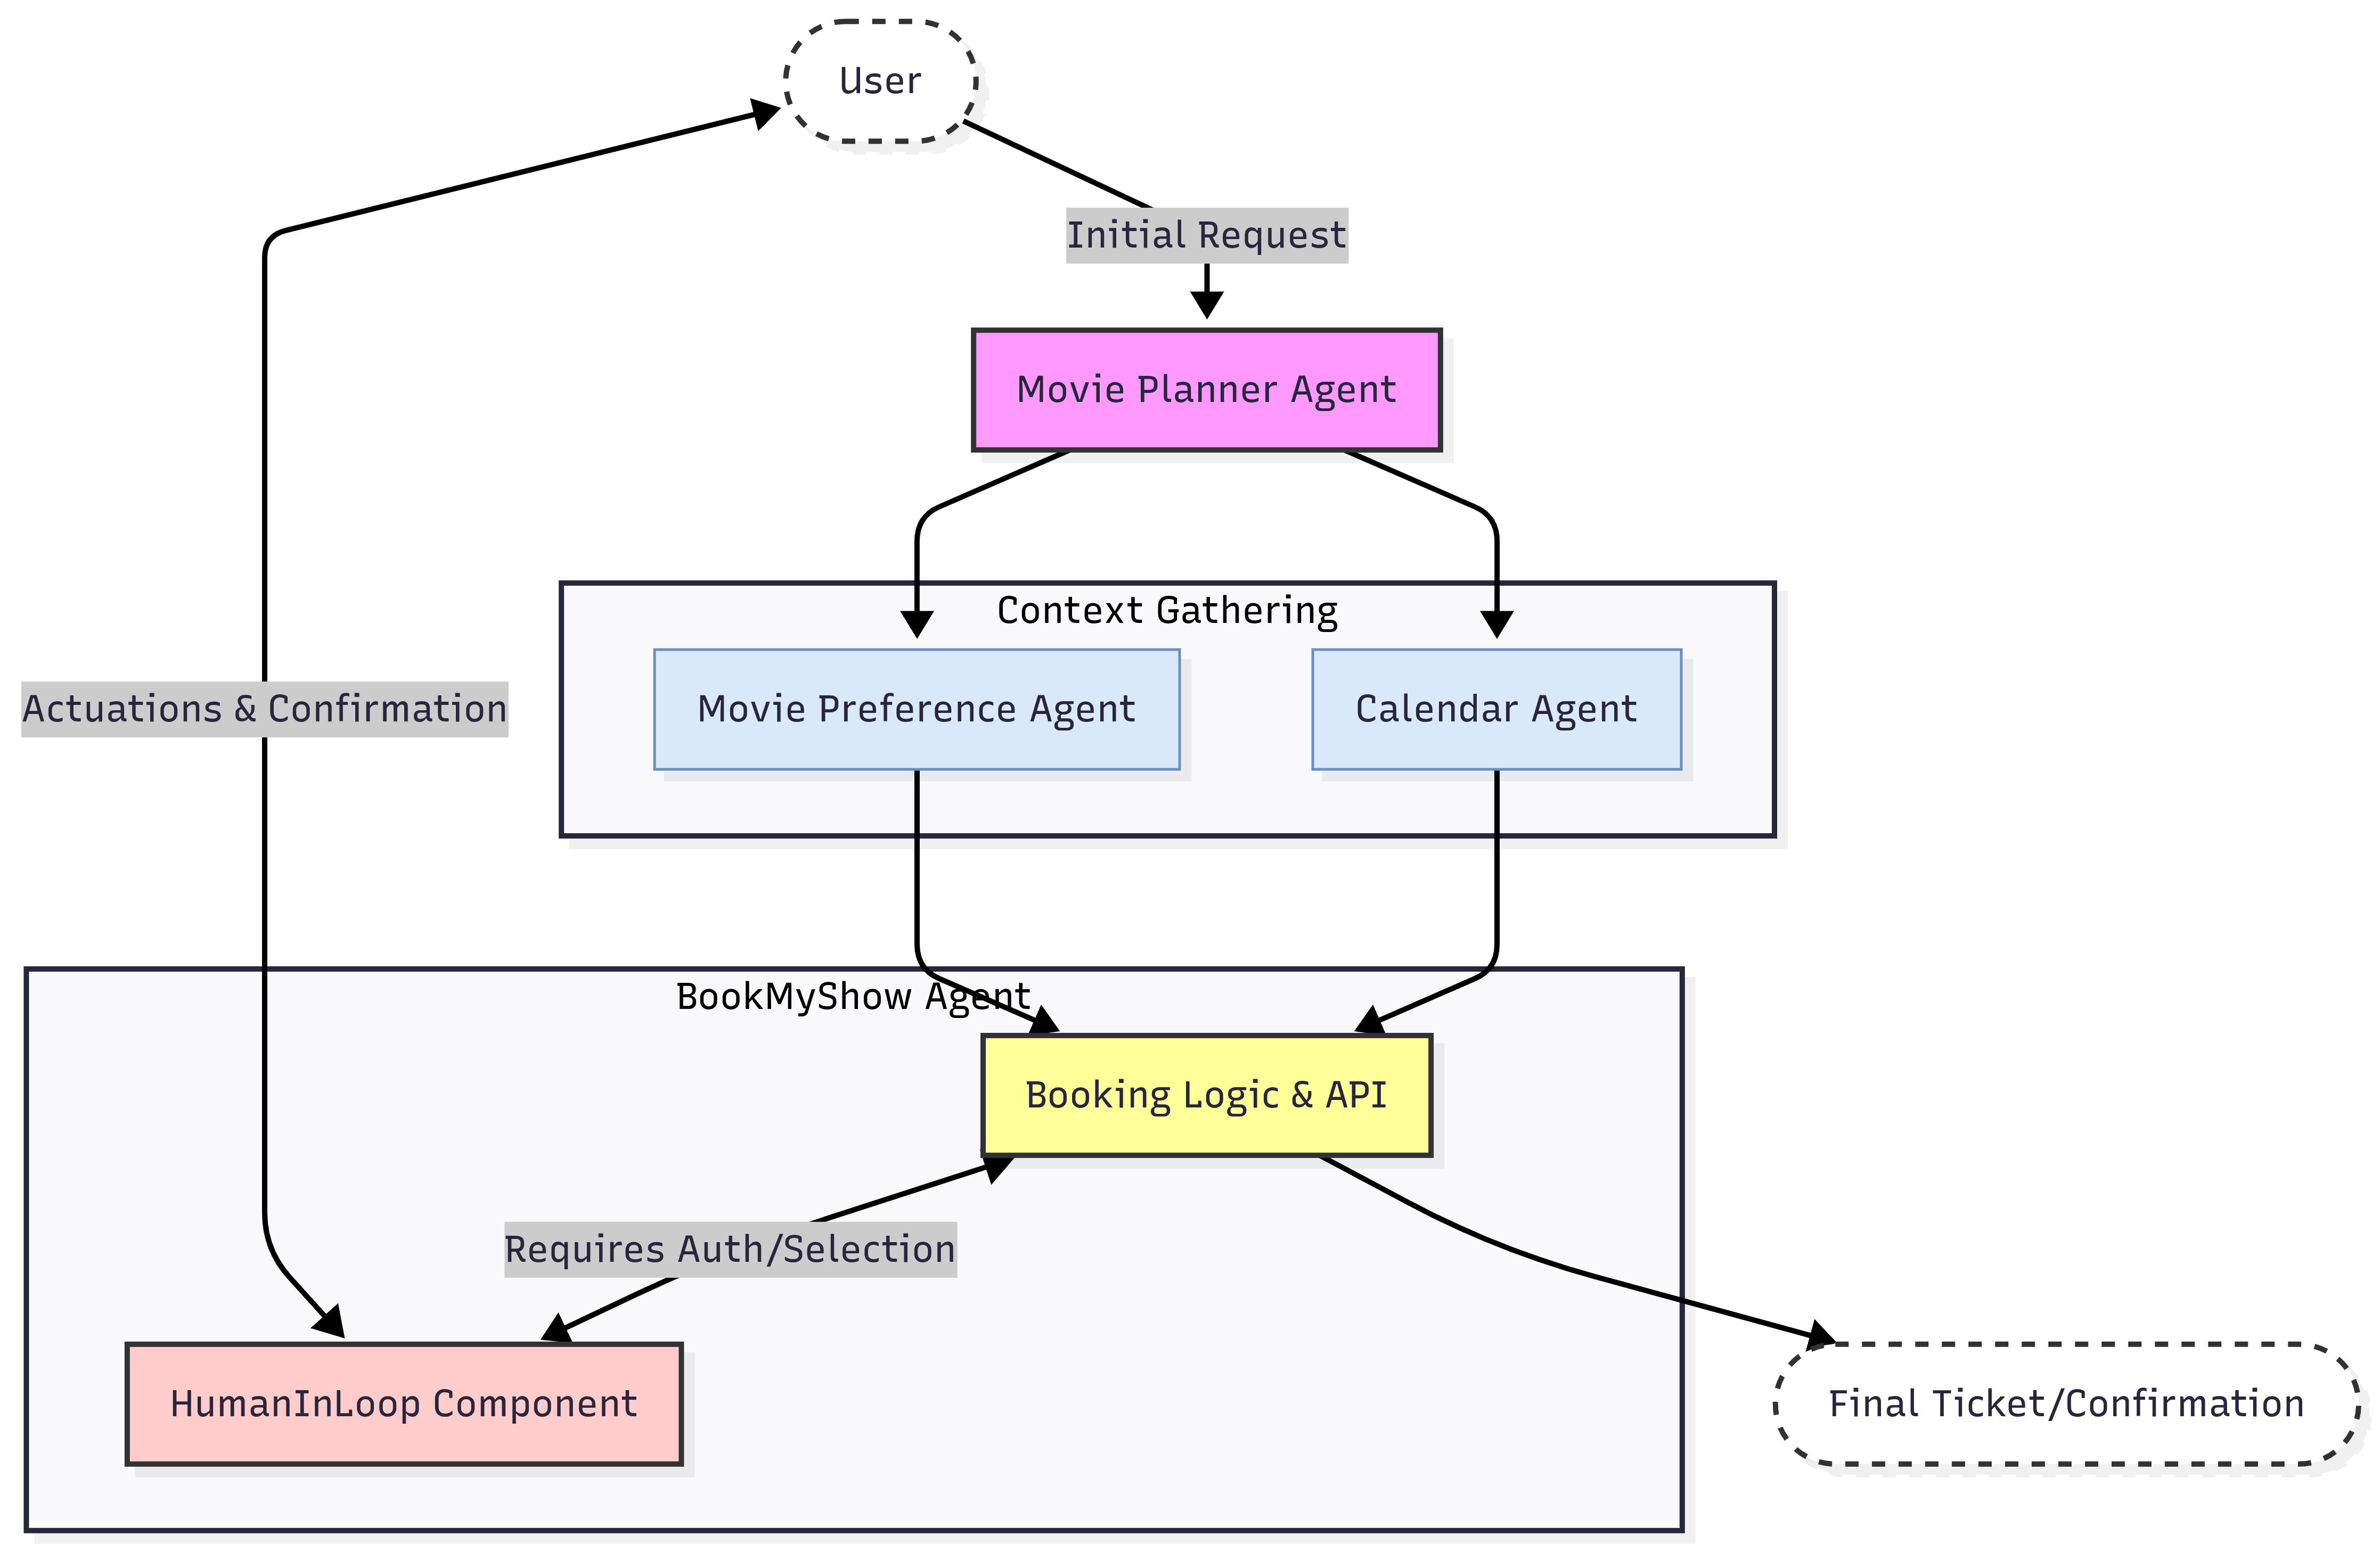

### HIL Integration Code
The `BookMyShowAgent` uses the `HisClient` to pause execution and wait for human input.

In [ ]:
# From agent_movieplanner_bookmyshow_agent.py
self.his_client = HisClient(
    base_url=HIS_BASE_URL,
    poll_interval=HIS_POLL_INTERVAL,
    max_wait=HIS_MAX_WAIT,
)

def on_data(self, task: AgentTask) -> AgentResult:
    # ... aggregation logic ...
    
    # SUBMIT TO HIS AND WAIT FOR HUMAN
    obj = self.his_client.submit_and_wait(
        input_data={
            "task": "Choose Your Movie Option",
            "text": final_list,
            "Analysis": reasoning
        }
    )

    user_choice_raw = obj.response_data.get("user_choice", "")
    # ... proceed with user_choice_raw ...

### Agent Roles & Source Files

| Agent Role | Source File | Responsibilities |
| :--- | :--- | :--- |
| **Planner (Orchestrator)** | [`agent_movieplanner_planner_agent.py`](agent_codes/agent_movieplanner_planner_agent.py) | Parses request, sets strategy, and delegates to specialists. |
| **Calendar Specialist** | [`agent_movieplanner_calendar_agent.py`](agent_codes/agent_movieplanner_calendar_agent.py) | Queries user's schedule to find free slots. |
| **Preference Specialist** | [`agent_movieplanner_preference_agent.py`](agent_codes/agent_movieplanner_preference_agent.py) | Identifies genres/movies the user likes or avoids. |
| **BMS Aggregator (HIL)** | [`agent_movieplanner_bookmyshow_agent.py`](agent_codes/agent_movieplanner_bookmyshow_agent.py) | Matches data, triggers HIS for human choice, and finalizes. |

---

## 4. Execution Pipeline

1. **Agent Registration**: Register all RFC agents in the cluster.
   - Script: [register-agents.sh](../../agents_registration/6_human_in_loop_movie_planner/register-agents.sh)
2. **Deployment**: Spin up containers for the RFC evaluation flow.
   - Script: [deploy-agents.sh](../../agents_registration/6_human_in_loop_movie_planner/deploy-agents.sh)
3. **Triggering the Flow**: Send the initial RFC text to the **Summarizer**.
   - Script: [inference_request.sh](../../agents_registration/6_human_in_loop_movie_planner/inference_request.sh)
4. **All in One**: Run [all.bash](../../agents_registration/6_human_in_loop_movie_planner/all.bash) to do 
    - `1. Remove agents if already running` 
    - `2. Unregister agent` 
    - `3. Register agent` 
    - `4. Deploy agents again` 

#### Run all.bash to setup the RFC Flow

In [ ]:
%%bash
cd ../../agents_registration/6_human_in_loop_movie_planner
bash all.bash

#### Run Streamlit app for watching the agents in action

In [ ]:
%%bash --bg --proc my_bg_process
cd ../../agents_registration/6_human_in_loop_movie_planner
source ../../../venv/bin/activate
bash run_streamlit_app.bash

#### Open `http:{IP}:8003` in browser for streamlit app

#### Check for pods in agents namespace

In [ ]:
%%bash
kubectl get pods -n agents

##### Check Containers in a Pod

In [ ]:
kubectl get pod -n agents <PODNAME> -o jsonpath='{.spec.containers[*].name}'

##### Executor Containers
- executor: ratelimiting, config management, load balancing, autoscaling etc
- Scouter: responsible for scouting jobs in Job Exchange
 
* User can define the policy for above 

#### Trigger the First agent (Movie Planner)

In [ ]:
%%bash
echo "$PWD"
cd ../../agents_registration/6_human_in_loop_movie_planner
echo "$PWD"
bash inference_request.sh

#### To Remove the Agent Pods

In [ ]:
%%bash
cd ../../agents_registration/6_human_in_loop_movie_planner
bash remove-agents.sh

## Conclusion
The Human-in-Loop pattern is essential for high-stakes decisions like payments, bookings, or code reviews. By combining the speed of parallel agents with the reliability of human judgment, you can build trustable and robust agentic systems.